In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###SEÇÃO 7

In [1]:
!git clone https://github.com/masterAristocats/Proc-Sin-Trabalho-Extra.git

Cloning into 'Proc-Sin-Trabalho-Extra'...
remote: Enumerating objects: 182, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 182 (delta 8), reused 2 (delta 2), pack-reused 162 (from 1)
Receiving objects: 100% (182/182), 11.06 MiB | 25.98 MiB/s, done.
Resolving deltas: 100% (77/77), done.


In [3]:
%cd Proc-Sin-Trabalho-Extra

!ls src

[Errno 2] No such file or directory: 'Proc-Sin-Trabalho-Extra'
/content/Proc-Sin-Trabalho-Extra
beamformer.py	generate_uca.py   generate_ula.py  steering_vector.py
beampattern.py	generate_ucya.py  generate_upa.py


In [4]:
import numpy as np
import matplotlib.pyplot as plt

from src.generate_ula import generate_ula
from src.beamformer import beamformer
from src.steering_vector import steering_vector
from src.beampattern import beampattern

##Parâmetros do sistema

In [5]:
c = 3e8

fc = 1e9

wavelength = c / fc

M = 8

d = wavelength/2

theta_tx = np.deg2rad(20)

##Gerar transmissor e receptor

In [6]:
tx_positions = generate_ula(M, d)

rx_positions = generate_ula(M, d)

##Gerar o sinal

In [7]:
fs = 20000

t = np.arange(0,0.01,1/fs)

m = (
    np.sin(2*np.pi*500*t)
    +
    0.5*np.sin(2*np.pi*1500*t)
)

##Simular sinal recebido pelos sensores (θT = 20°)

In [8]:
# Vetor diretor do transmissor
a_tx = steering_vector(
    tx_positions,
    theta_tx,
    0,
    wavelength
)

# Sinais recebidos por cada sensor
# x possui dimensão (M, N_amostras)
x = a_tx[:, np.newaxis] * m

##Parte 1: Alinhamento perfeito (θR = 20°)

In [9]:
theta_rx = np.deg2rad(20)

y = np.zeros(len(t), dtype=complex)

for i in range(len(t)):
    y[i] = beamformer(
        x[:, i],
        rx_positions,
        (theta_rx, 0),
        wavelength
    )

#Potência recebida

In [10]:
power_tx = np.mean(m**2)

power_rx = np.mean(np.abs(y)**2)

link_gain = power_rx / power_tx

print(f"Potência transmitida : {power_tx:.4f}")
print(f"Potência recebida    : {power_rx:.4f}")
print(f"Ganho do enlace      : {link_gain:.4f}")

Potência transmitida : 0.6250
Potência recebida    : 0.6250
Ganho do enlace      : 1.0000


##Forma de onda

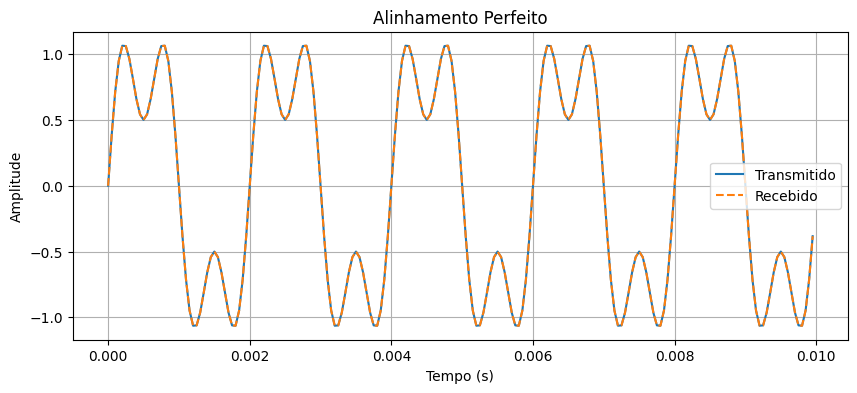

In [11]:
plt.figure(figsize=(10,4))

plt.plot(t, m, label="Transmitido")

plt.plot(
    t,
    np.real(y),
    "--",
    label="Recebido"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")

plt.title("Alinhamento Perfeito")

plt.grid(True)

plt.legend()

plt.show()

##Parte 2: Desalinhamento angular

In [12]:
angles = np.array([
    -90,
    -60,
    -30,
    0,
    10,
    20,
    30,
    60,
    90
])

powers = []
gains = []
correlations = []

##Calcular potência, ganho e correlação

In [13]:
for angle in angles:

    theta_rx = np.deg2rad(angle)

    y = np.zeros(len(t), dtype=complex)

    for i in range(len(t)):

        y[i] = beamformer(
            x[:, i],
            rx_positions,
            (theta_rx, 0),
            wavelength
        )

    power = np.mean(np.abs(y)**2)

    gain = power / power_tx

    corr = np.corrcoef(
        m,
        np.real(y)
    )[0,1]

    powers.append(power)
    gains.append(gain)
    correlations.append(corr)

##resultados

In [14]:
print("Ângulo | Potência | Ganho | Correlação")

for a, p, g, c in zip(
    angles,
    powers,
    gains,
    correlations
):

    print(
        f"{a:>4}°   "
        f"{p:.4f}   "
        f"{g:.4f}   "
        f"{c:.4f}"
    )

Ângulo | Potência | Ganho | Correlação
 -90°   0.0047   0.0074   1.0000
 -60°   0.0114   0.0182   -1.0000
 -30°   0.4677   0.7484   1.0000
   0°   0.5157   0.8251   1.0000
  10°   0.5618   0.8989   1.0000
  20°   0.6250   1.0000   1.0000
  30°   0.4677   0.7484   1.0000
  60°   0.0114   0.0182   -1.0000
  90°   0.0047   0.0074   1.0000


##Parte 3: Variação contínua

In [15]:
theta_scan = np.linspace(-90,90,181)

power_curve = []
gain_curve = []

##Calcular para todos os ângulos

In [16]:
for angle in theta_scan:

    theta_rx = np.deg2rad(angle)

    y = np.zeros(len(t), dtype=complex)

    for i in range(len(t)):

        y[i] = beamformer(
            x[:, i],
            rx_positions,
            (theta_rx,0),
            wavelength
        )

    power = np.mean(np.abs(y)**2)

    power_curve.append(power)

    gain_curve.append(power/power_tx)

##Potência X θR

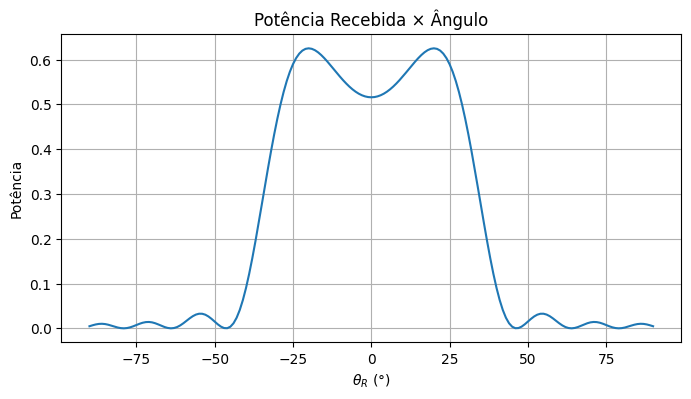

In [17]:
plt.figure(figsize=(8,4))

plt.plot(theta_scan, power_curve)

plt.grid(True)

plt.xlabel(r"$\theta_R$ (°)")
plt.ylabel("Potência")

plt.title("Potência Recebida × Ângulo")

plt.show()

##Ganho X θR

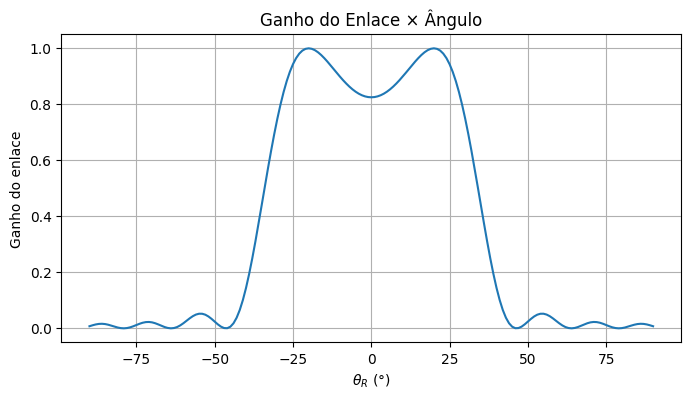

In [18]:
plt.figure(figsize=(8,4))

plt.plot(theta_scan, gain_curve)

plt.grid(True)

plt.xlabel(r"$\theta_R$ (°)")
plt.ylabel("Ganho do enlace")

plt.title("Ganho do Enlace × Ângulo")

plt.show()

##Comparação com o beampattern

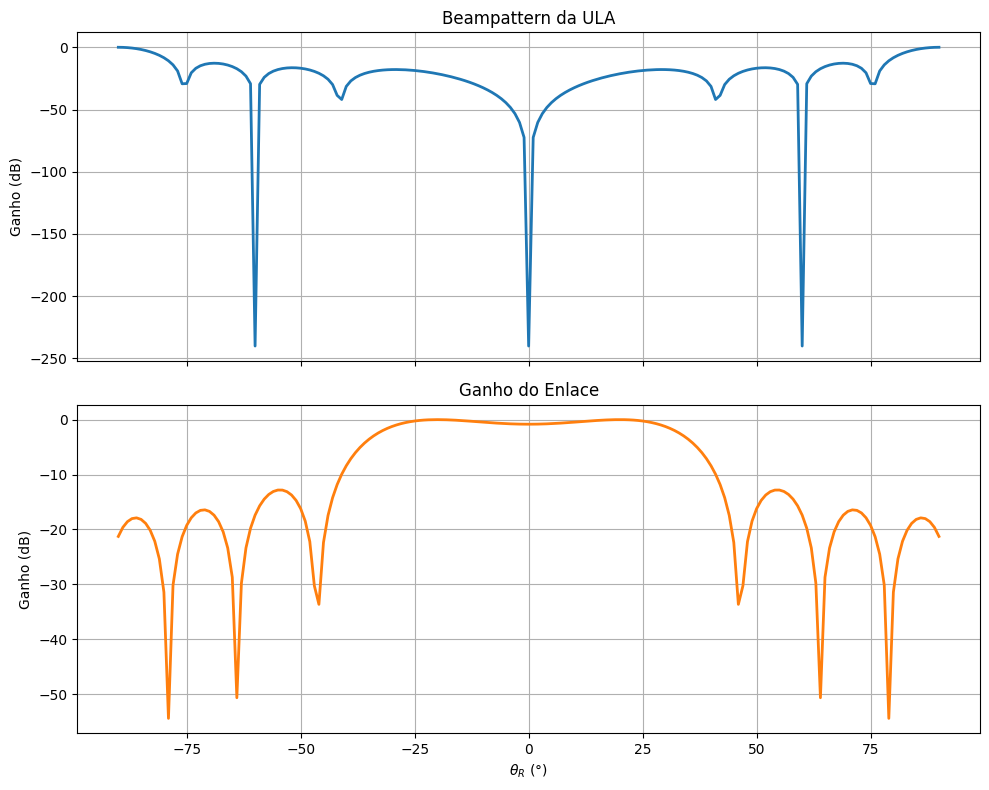

In [19]:
# ===============================
# Comparação com o beampattern
# ===============================

# Beampattern da ULA
gain_bp = beampattern(
    positions=rx_positions,
    azimuth=0,
    elevation=np.deg2rad(theta_scan),
    wavelength=wavelength
)

# Ganho do enlace em dB
gain_curve_db = 10 * np.log10(
    np.maximum(gain_curve, 1e-12)
)

# ===============================
# Gráficos
# ===============================

fig, ax = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True
)

# -------------------------------
# Beampattern
# -------------------------------

ax[0].plot(
    theta_scan,
    gain_bp,
    linewidth=2
)

ax[0].set_title("Beampattern da ULA")

ax[0].set_ylabel("Ganho (dB)")

ax[0].grid(True)

# -------------------------------
# Ganho do enlace
# -------------------------------

ax[1].plot(
    theta_scan,
    gain_curve_db,
    linewidth=2,
    color="tab:orange"
)

ax[1].set_title("Ganho do Enlace")

ax[1].set_xlabel(r"$\theta_R$ (°)")
ax[1].set_ylabel("Ganho (dB)")

ax[1].grid(True)

plt.tight_layout()

plt.show()

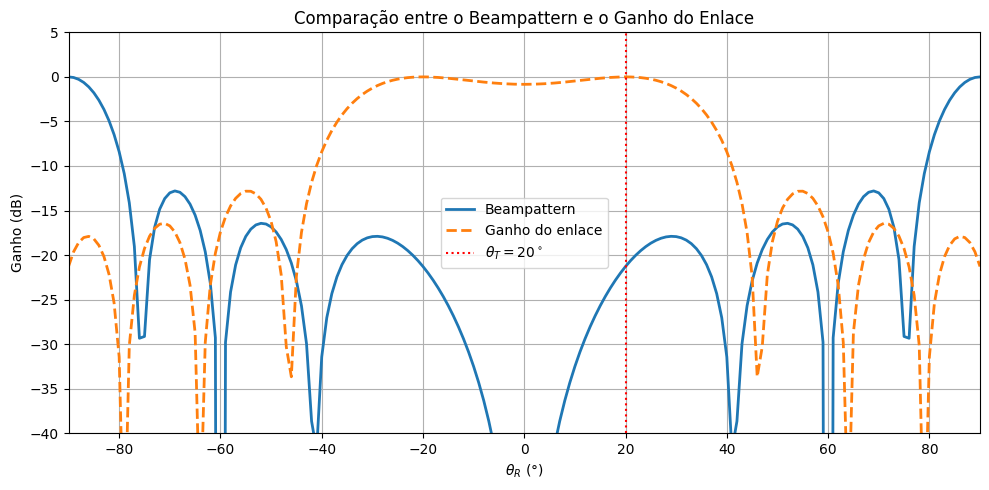

In [20]:
# ===============================
# Comparação com o beampattern
# ===============================

# Beampattern da ULA
gain_bp = beampattern(
    positions=rx_positions,
    azimuth=0,
    elevation=np.deg2rad(theta_scan),
    wavelength=wavelength
)

# Ganho do enlace em dB
gain_curve_db = 10 * np.log10(
    np.maximum(gain_curve, 1e-12)
)

# ===============================
# Gráfico comparativo
# ===============================

plt.figure(figsize=(10, 5))

plt.plot(
    theta_scan,
    gain_bp,
    linewidth=2,
    label="Beampattern"
)

plt.plot(
    theta_scan,
    gain_curve_db,
    "--",
    linewidth=2,
    label="Ganho do enlace"
)

# Direção de apontamento
plt.axvline(
    20,
    color="red",
    linestyle=":",
    linewidth=1.5,
    label=r"$\theta_T = 20^\circ$"
)

plt.title("Comparação entre o Beampattern e o Ganho do Enlace")

plt.xlabel(r"$\theta_R$ (°)")
plt.ylabel("Ganho (dB)")

plt.xlim(-90, 90)
plt.ylim(-40, 5)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()